In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import catboost, lightgbm, xgboost
import pycaret.classification

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, loguniform, randint

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
def print_metrics(*metrics, y_true, y_pred):
    metrics_names = {
        classification_report: 'classification_report',
        confusion_matrix: 'confusion_matrix',
    }

    for metric in metrics:
        score = metric(y_true, y_pred)
        print(metrics_names[metric])
        print(score)

# Загрузка и подготовка данных

In [3]:
data = pd.read_csv('/Users/macbook/Desktop/ВУЗ/Машинное обучение и большие данные/lab_1/heart.csv')

y = data['num']
X = data.drop(columns=['num'])

num_map = {0:0, 1:1, 2:1, 3:1, 4:1}
y = y.map(num_map)

In [4]:
y.value_counts()

num
0    160
1    133
Name: count, dtype: int64

## SMOTE

In [5]:
smote = SMOTE(random_state=42)

X_smt, y_smt = smote.fit_resample(X, y)

In [6]:
scaler = RobustScaler()

In [7]:
X_smt_train, X_smt_test, y_smt_train, y_smt_test = train_test_split(X_smt, y_smt, test_size=0.2, random_state=42, stratify=y_smt, shuffle=True)

X_smt_train = scaler.fit_transform(X_smt_train)
X_smt_test = scaler.transform(X_smt_test)

# Решение задачи классификации

### DecisionTreeClassifier

In [8]:
model = DecisionTreeClassifier()
model.fit(X_smt_train, y_smt_train)

y_pred_test = model.predict(X_smt_test)
y_pred_train = model.predict(X_smt_train)

In [9]:
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()

Train
classification_report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       128
           1       1.00      1.00      1.00       128

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256

confusion_matrix
[[128   0]
 [  0 128]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.72      0.66      0.69        32
           1       0.69      0.75      0.72        32

    accuracy                           0.70        64
   macro avg       0.70      0.70      0.70        64
weighted avg       0.70      0.70      0.70        64

confusion_matrix
[[21 11]
 [ 8 24]]



### BaggingClassifier

In [10]:
algorithms = [DecisionTreeClassifier(), LogisticRegression(), GaussianNB(), KNeighborsClassifier(), SVC()]

In [11]:
for algorithm in algorithms:    
    print(str(algorithm)[:-2])
    bagging_model = BaggingClassifier(estimator=algorithm)
    bagging_model.fit(X_smt_train, y_smt_train)

    y_pred_test = bagging_model.predict(X_smt_test)
    y_pred_train = bagging_model.predict(X_smt_train)
    print('Train')
    print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
    print()
    print('Test')
    print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
    print()
    print('-' * 30)


DecisionTreeClassifier
Train
classification_report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       128
           1       1.00      0.98      0.99       128

    accuracy                           0.99       256
   macro avg       0.99      0.99      0.99       256
weighted avg       0.99      0.99      0.99       256

confusion_matrix
[[128   0]
 [  2 126]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.81      0.91      0.85        32

    accuracy                           0.84        64
   macro avg       0.85      0.84      0.84        64
weighted avg       0.85      0.84      0.84        64

confusion_matrix
[[25  7]
 [ 3 29]]

------------------------------
LogisticRegression
Train
classification_report
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       128
   

### RandomForestClassifier

In [12]:
bagging_model = RandomForestClassifier()
bagging_model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Train
classification_report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       128
           1       1.00      1.00      1.00       128

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256

confusion_matrix
[[128   0]
 [  0 128]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.86      0.78      0.82        32
           1       0.80      0.88      0.84        32

    accuracy                           0.83        64
   macro avg       0.83      0.83      0.83        64
weighted avg       0.83      0.83      0.83        64

confusion_matrix
[[25  7]
 [ 4 28]]

------------------------------


### GradientBoostingClassifier

In [13]:
bagging_model = GradientBoostingClassifier()
bagging_model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Train
classification_report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       128
           1       1.00      0.99      1.00       128

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256

confusion_matrix
[[128   0]
 [  1 127]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        32
           1       0.76      0.81      0.79        32

    accuracy                           0.78        64
   macro avg       0.78      0.78      0.78        64
weighted avg       0.78      0.78      0.78        64

confusion_matrix
[[24  8]
 [ 6 26]]

------------------------------


### StackingClassifier

In [14]:
bagging_model = StackingClassifier(estimators=[
        ('dt', DecisionTreeClassifier()),
        ('svc', SVC()),
        ('knn', KNeighborsClassifier()),
        ('gnb', GaussianNB())
    ], final_estimator=LogisticRegression())
bagging_model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       128
           1       0.94      0.91      0.92       128

    accuracy                           0.92       256
   macro avg       0.92      0.92      0.92       256
weighted avg       0.92      0.92      0.92       256

confusion_matrix
[[120   8]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

------------------------------


### CatBoostClassifier

In [15]:
model = catboost.CatBoostClassifier(verbose=200)
model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Learning rate set to 0.005758
0:	learn: 0.6897688	total: 55.1ms	remaining: 55s
200:	learn: 0.3150140	total: 172ms	remaining: 684ms
400:	learn: 0.2104758	total: 291ms	remaining: 434ms
600:	learn: 0.1542422	total: 407ms	remaining: 270ms
800:	learn: 0.1176446	total: 576ms	remaining: 143ms
999:	learn: 0.0920873	total: 686ms	remaining: 0us
Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       128
           1       0.94      0.91      0.92       128

    accuracy                           0.92       256
   macro avg       0.92      0.92      0.92       256
weighted avg       0.92      0.92      0.92       256

confusion_matrix
[[120   8]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.7

### LGBMClassifier

In [16]:
model = lightgbm.LGBMClassifier(verbose=-1)
model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       128
           1       0.94      0.91      0.92       128

    accuracy                           0.92       256
   macro avg       0.92      0.92      0.92       256
weighted avg       0.92      0.92      0.92       256

confusion_matrix
[[120   8]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

------------------------------


### XGBClassifier

In [17]:
model = xgboost.XGBClassifier()
model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       128
           1       0.94      0.91      0.92       128

    accuracy                           0.92       256
   macro avg       0.92      0.92      0.92       256
weighted avg       0.92      0.92      0.92       256

confusion_matrix
[[120   8]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

------------------------------


# Подбор гиперпараметров

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### DecisionTreeClassifier

In [19]:
params = {
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(1, 40),
    'max_features': ['sqrt', 'log2', None],
    'max_leaf_nodes': randint(2, 20),
    'ccp_alpha': uniform(0.01, 0.05)
}

Лучшие параметры: {'ccp_alpha': 0.014604143048181625, 'max_depth': 19, 'max_features': None, 'max_leaf_nodes': 7, 'min_samples_leaf': 14, 'min_samples_split': 30}
Лучший score: 0.815819774623877
Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       128
           1       0.94      0.91      0.92       128

    accuracy                           0.92       256
   macro avg       0.92      0.92      0.92       256
weighted avg       0.92      0.92      0.92       256

confusion_matrix
[[120   8]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

------------------

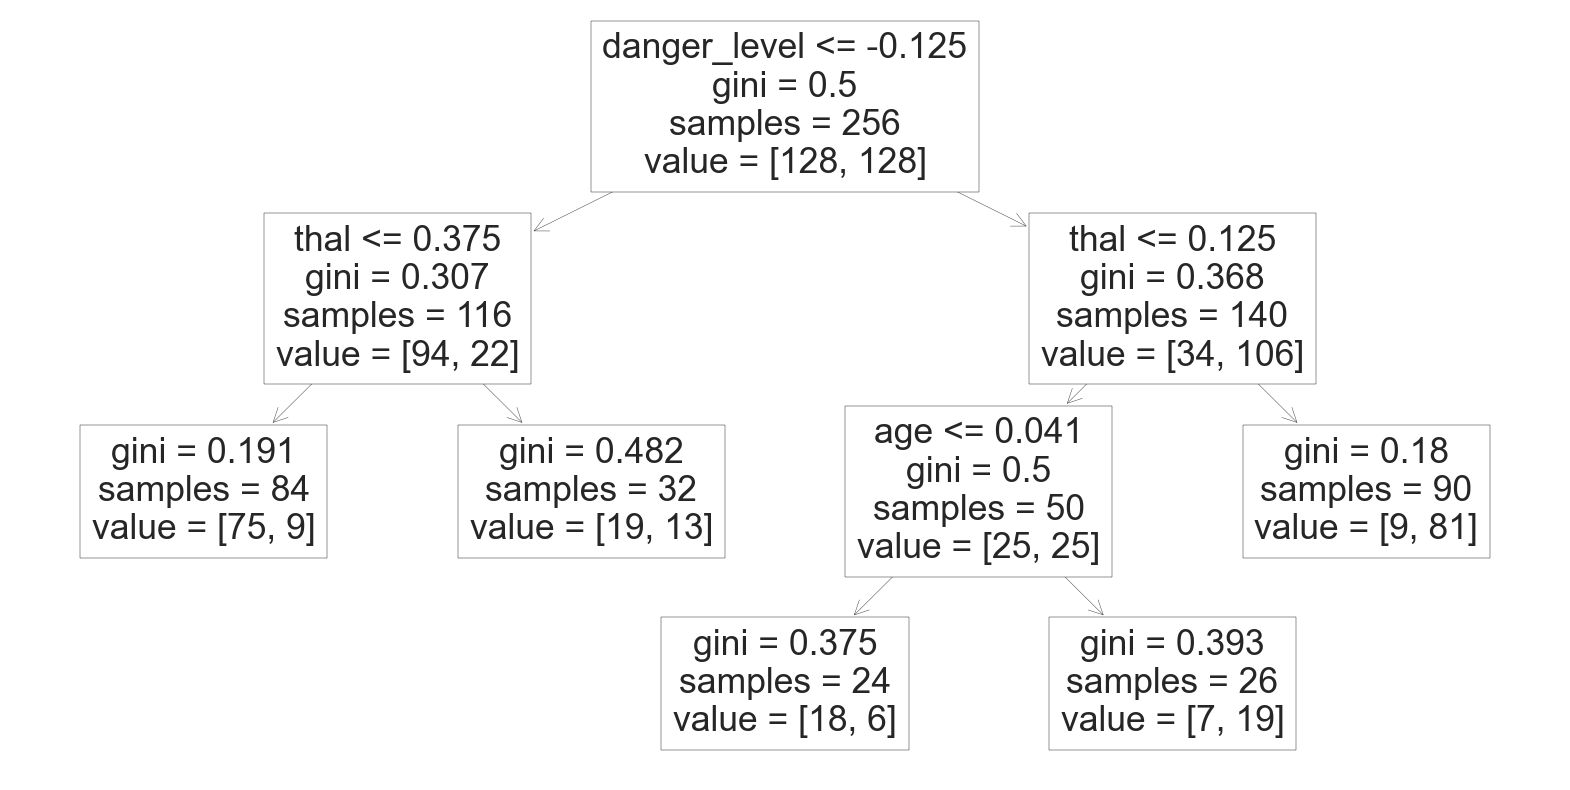

In [20]:
model = DecisionTreeClassifier(criterion='gini', class_weight='balanced', splitter='best', random_state=42)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

plt.figure(figsize=(20, 10))
plot_tree(rs.best_estimator_, feature_names=X.columns)
plt.show()

### BaggingClassifier

In [21]:
params = {
    'n_estimators': randint(2, 100),
    'max_samples': uniform(0.1, 0.9),
    'max_features': uniform(0.1, 0.9),
}

In [22]:
model = BaggingClassifier(estimator=DecisionTreeClassifier(criterion='gini', splitter='best', random_state=42), bootstrap=True, bootstrap_features=True)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

KeyboardInterrupt: 

### RandomForestClassifier

In [ ]:
params = {
    'n_estimators': randint(2, 100),
    'max_depth': randint(2, 5),
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(10, 40),
    'max_leaf_nodes': randint(2, 20),
}

In [ ]:
model = RandomForestClassifier(criterion='gini', max_features=1/3, max_samples=1.0, bootstrap=True, random_state=42)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Лучшие параметры: {'max_depth': 4, 'max_leaf_nodes': 11, 'min_samples_leaf': 23, 'min_samples_split': 30, 'n_estimators': 61}
Лучший score: 0.8022487478764766
Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       128
           1       0.94      0.91      0.92       128

    accuracy                           0.92       256
   macro avg       0.92      0.92      0.92       256
weighted avg       0.92      0.92      0.92       256

confusion_matrix
[[120   8]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

------------------------------


### GradientBoostingClassifier

In [ ]:
params = {
    'learning_rate': uniform(0.1, 0.5),
    'n_estimators': randint(2, 100),
    'max_depth': randint(1, 3),
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(10, 40),
    'max_leaf_nodes': randint(2, 20),
    'ccp_alpha': uniform(0.0, 0.3)
}

In [ ]:
model = GradientBoostingClassifier(loss='log_loss', subsample=1.0, criterion='friedman_mse', random_state=42, max_features=1/3)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Лучшие параметры: {'ccp_alpha': 0.025302534705116675, 'learning_rate': 0.1516985433024904, 'max_depth': 2, 'max_leaf_nodes': 14, 'min_samples_leaf': 26, 'min_samples_split': 33, 'n_estimators': 9}
Лучший score: 0.7868290361669785
Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       128
           1       0.94      0.91      0.92       128

    accuracy                           0.92       256
   macro avg       0.92      0.92      0.92       256
weighted avg       0.92      0.92      0.92       256

confusion_matrix
[[120   8]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[2

### StackingClassifier

In [ ]:
bagging_model = StackingClassifier(estimators=[
        ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
        ('svc', SVC(kernel='poly', C=1, coef0=0.5, degree=3, gamma=0.01)),
        ('knn', KNeighborsClassifier(leaf_size=10, metric='manhattan', n_neighbors=3, weights='distance')),
        ('gnb', GaussianNB(var_smoothing=1e-15))
    ], final_estimator=LogisticRegression(), cv=5)

bagging_model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()

Train
classification_report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       128
           1       0.96      0.96      0.96       128

    accuracy                           0.96       256
   macro avg       0.96      0.96      0.96       256
weighted avg       0.96      0.96      0.96       256

confusion_matrix
[[123   5]
 [  5 123]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        32
           1       0.79      0.81      0.80        32

    accuracy                           0.80        64
   macro avg       0.80      0.80      0.80        64
weighted avg       0.80      0.80      0.80        64

confusion_matrix
[[25  7]
 [ 6 26]]



### CatBoostClassifier

In [23]:
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

In [24]:
params = {
    'iterations': randint(2, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'depth': randint(4, 10),
    'grow_policy': ['SymmetricTree', 'Depthwise', 'Lossguide']
}

In [ ]:
model = catboost.CatBoostClassifier(loss_function='Logloss', bootstrap_type='Bayesian', bagging_temperature=1, random_state=42, verbose=0)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Лучшие параметры: {'depth': 8, 'grow_policy': 'Depthwise', 'iterations': 939, 'learning_rate': 0.09032639028790011}
Лучший score: 0.8432050877150361
Train
classification_report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       128
           1       0.96      0.96      0.96       128

    accuracy                           0.96       256
   macro avg       0.96      0.96      0.96       256
weighted avg       0.96      0.96      0.96       256

confusion_matrix
[[123   5]
 [  5 123]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        32
           1       0.79      0.81      0.80        32

    accuracy                           0.80        64
   macro avg       0.80      0.80      0.80        64
weighted avg       0.80      0.80      0.80        64

confusion_matrix
[[25  7]
 [ 6 26]]

------------------------------


### XGBClassifier

In [25]:
params = {
    'n_estimators': randint(2, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(4, 10),
    'booster': ['gbtree', 'gblinear', 'dart'],
}

In [26]:
model = xgboost.XGBClassifier(objective='binary:logistic', verbosity=2)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=5, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

[00:27:01] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[00:27:01] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[00:27:01] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[00:27:01] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[00:27:01] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[00:27:01] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[00:27:01] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[00:27:01] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[00:27:01] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[00:27:01] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1


### LGBMClassifier

In [27]:
params = {
    'n_estimators': randint(2, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(4, 10),
    'boosting_type': ['gbdt', 'dart', 'goss', 'rf'],
}

In [28]:
model = lightgbm.LGBMClassifier(objective='binary')

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=20, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) 

Лучшие параметры: {'boosting_type': 'gbdt', 'learning_rate': 0.3045068925924521, 'max_depth': 6, 'n_estimators': 906}
Лучший score: 0.8197288191627577
Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       128
           1       0.94      0.91      0.92       128

    accuracy                           0.92       256
   macro avg       0.92      0.92      0.92       256
weighted avg       0.92      0.92      0.92       256

confusion_matrix
[[120   8]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

------------------------------


## PyCaret

In [34]:
from pycaret.classification import setup, compare_models, tune_model, get_config, predict_model, models

In [36]:
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [35]:
reg = setup(data=data, target='num', session_id=42, normalize=True, normalize_method='robust')

best_model = compare_models()

,Description,Value
0,Session id,42
1,Target,num
2,Target type,Multiclass
3,Original data shape,"(293, 16)"
4,Transformed data shape,"(293, 16)"
5,Transformed train set shape,"(205, 16)"
6,Transformed test set shape,"(88, 16)"
7,Numeric features,15
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.6100,0.0000,0.6100,0.5938,0.5813,0.3518,0.3646,0.0080
ridge,Ridge Classifier,0.6100,0.0000,0.6100,0.5237,0.5460,0.3109,0.3338,0.0040
lda,Linear Discriminant Analysis,0.6098,0.0000,0.6098,0.5841,0.5858,0.3604,0.3681,0.0040
rf,Random Forest Classifier,0.6002,0.6736,0.6002,0.5249,0.5457,0.3011,0.3156,0.0260
lightgbm,Light Gradient Boosting Machine,0.5952,0.6593,0.5952,0.5850,0.5709,0.3301,0.3402,0.5770
catboost,CatBoost Classifier,0.5950,0.6528,0.5950,0.5735,0.5645,0.3194,0.3311,0.2540
et,Extra Trees Classifier,0.5857,0.6624,0.5857,0.5183,0.5332,0.2783,0.2936,0.0200
svm,SVM - Linear Kernel,0.5757,0.0000,0.5757,0.5194,0.5238,0.2956,0.3180,0.0070
xgboost,Extreme Gradient Boosting,0.5755,0.6497,0.5755,0.5426,0.5466,0.3056,0.3131,0.0120
gbc,Gradient Boosting Classifier,0.5562,0.0000,0.5562,0.5129,0.5200,0.2573,0.2644,0.0350


In [37]:
tuned_model = tune_model(best_model)

X_train = get_config('X_train')
y_train = get_config('y_train')
X_test = get_config('X_test')
y_test = get_config('y_test')

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6667,0.0000,0.6667,0.6696,0.6402,0.4576,0.4681
1,0.8095,0.0000,0.8095,0.8373,0.7867,0.7011,0.7230
2,0.4762,0.0000,0.4762,0.4310,0.4523,0.1691,0.1705
3,0.5238,0.0000,0.5238,0.4127,0.4614,0.1633,0.1749
4,0.3810,0.0000,0.3810,0.4156,0.3975,0.0387,0.0392
5,0.5500,0.0000,0.5500,0.5167,0.4981,0.1818,0.1964
6,0.7500,0.0000,0.7500,0.7917,0.7592,0.5918,0.5970
7,0.6000,0.0000,0.6000,0.4631,0.5155,0.3361,0.3558
8,0.6500,0.0000,0.6500,0.7667,0.6738,0.4737,0.4941


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       128
           1       0.94      0.91      0.92       128

    accuracy                           0.92       256
   macro avg       0.92      0.92      0.92       256
weighted avg       0.92      0.92      0.92       256

confusion_matrix
[[120   8]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

-